<a href="https://colab.research.google.com/github/shifu027/TCC-Pyomo/blob/main/Pymo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ambiente pronto.
Pico da carga agregada às 19h: 1100.0 kW
Nós da rede: [0, 1, 2, 3, 4, 5, 6] | SLACK: 0
Executando: BAU ...
Executando: BESS+V1G ...
Executando: BESS+V2G ...
Cenários executados.

--- KPIs (numéricos crus) ---
          Custo Total (R$)  Custo de Energia (R$)  Custo de Demanda (R$)  \
Cenário                                                                    
BAU            8887.557882            8858.947882                    0.0   
BESS+V1G       7478.851052            7456.027364                    0.0   
BESS+V2G       7436.116052            7410.887364                    0.0   

          Custo de Degradação (R$)  Pico de Demanda (kW)  \
Cenário                                                    
BAU                      28.610000                1125.4   
BESS+V1G                 22.823688                1100.0   
BESS+V2G                 25.228688                1092.6   

          Energia Importada (kWh)  Energia PV Curtailada (kWh)  \
Cenário                   

,Custo Total (R$),Custo de Energia (R$),Custo de Demanda (R$),Custo de Degradação (R$),Pico de Demanda (kW),Energia Importada (kWh),Energia PV Curtailada (kWh),Tensão Mínima (p.u.),Redução Custo Total (%),Redução Pico Demanda (%)
Cenário,,,,,,,,,,
BAU,"8.887,56","8.858,95","0,00","28,61","1.125,40","9.815,44","0,00","0,96","0,00","0,00"
BESS+V1G,"7.478,85","7.456,03","0,00","22,82","1.100,00","8.261,92","293,22","0,96","15,85","2,26"
BESS+V2G,"7.436,12","7.410,89","0,00","25,23","1.092,60","8.213,82","293,22","0,96","16,33","2,91"


Arquivos salvos: /content/figs/kpi_comparativo_BR.csv | /content/figs/kpi_comparativo_BR.md


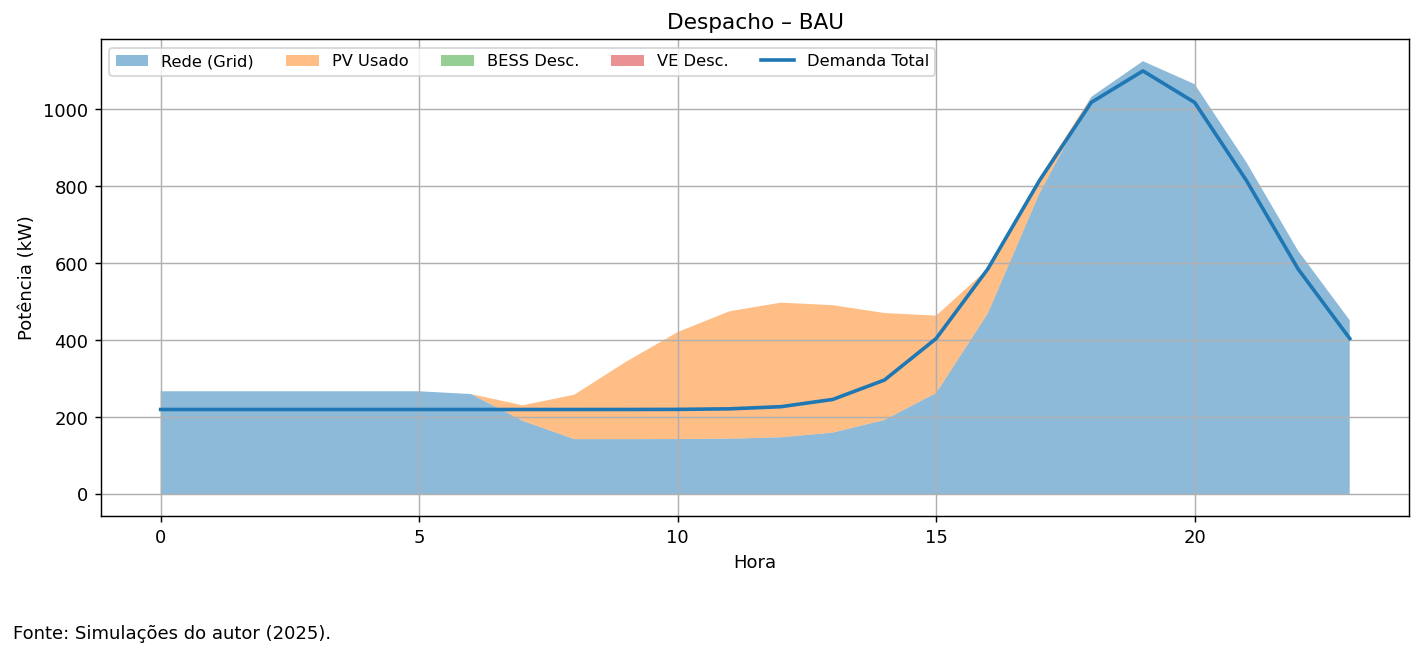

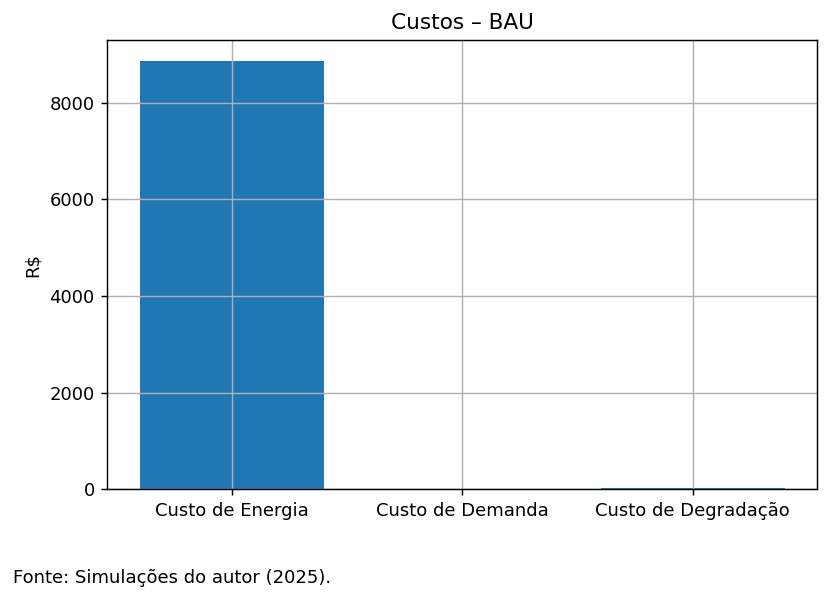

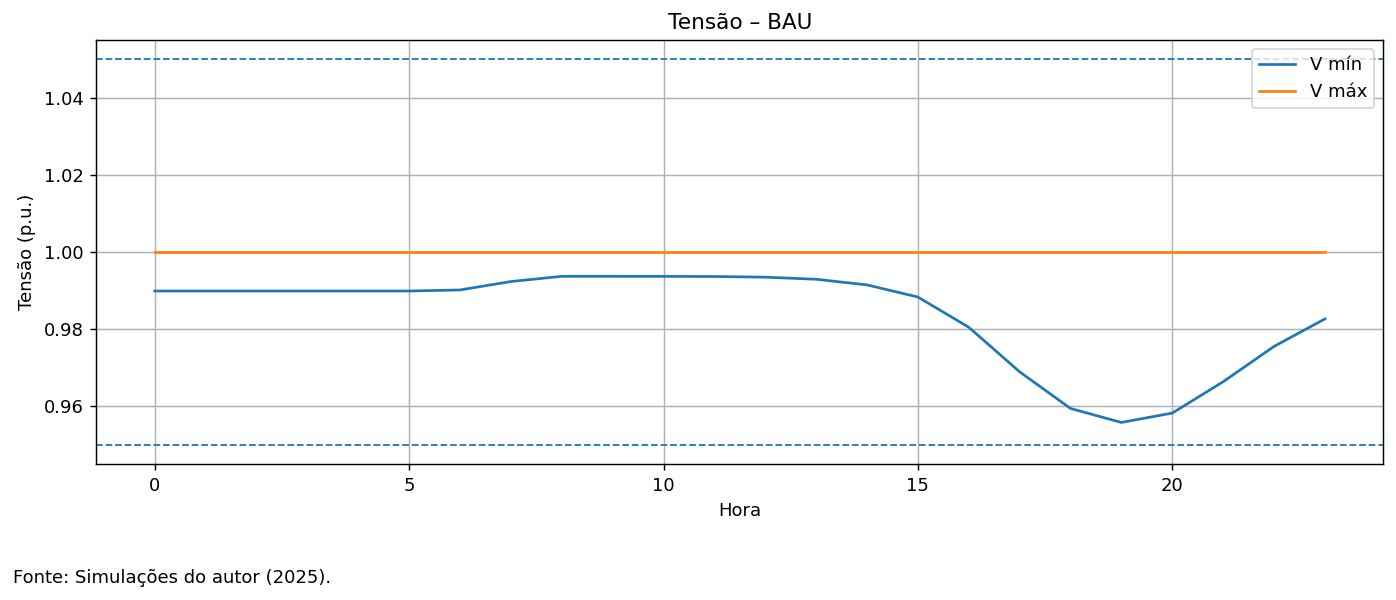

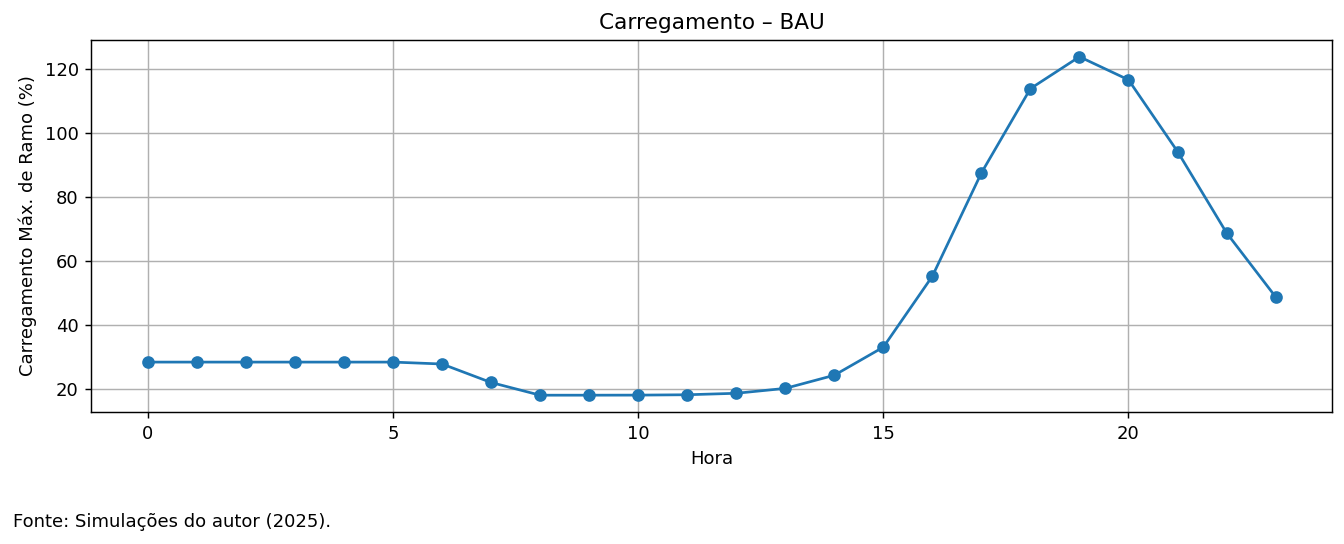

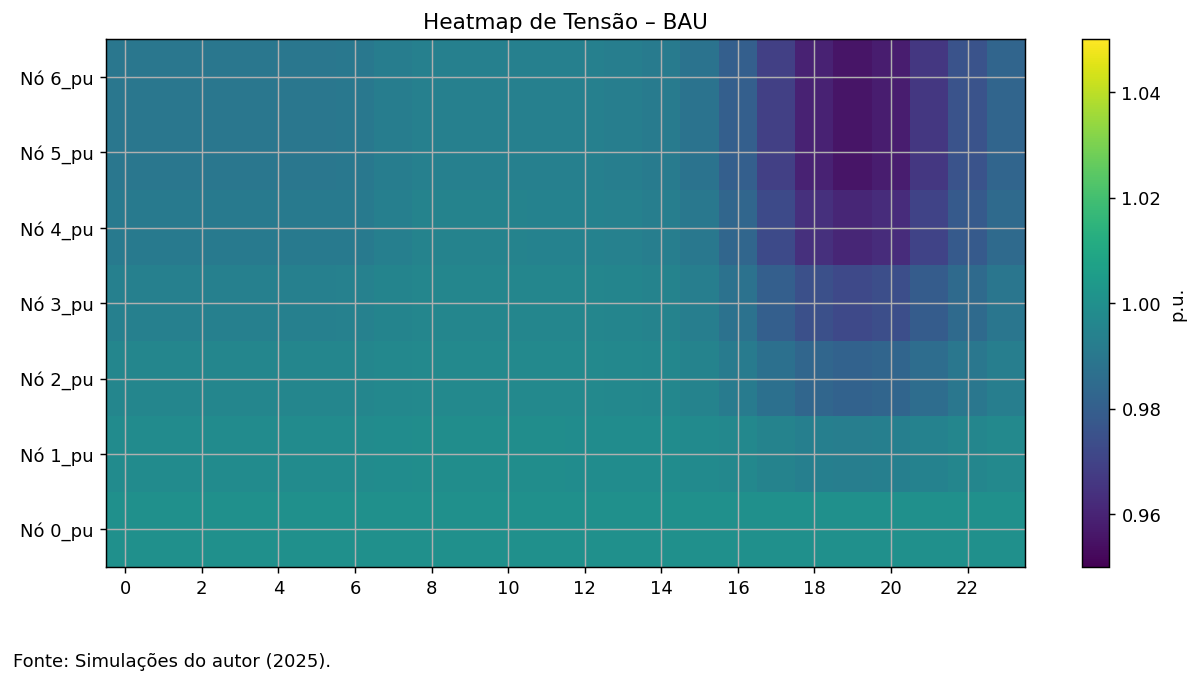

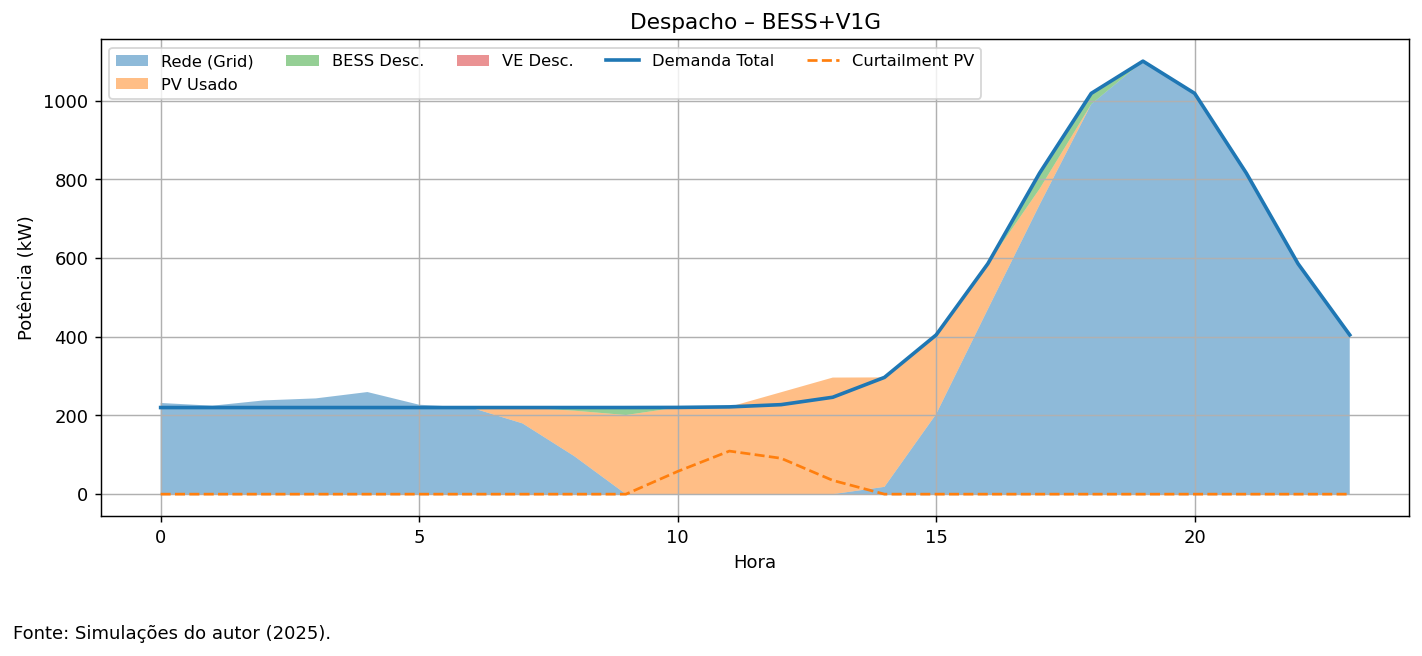

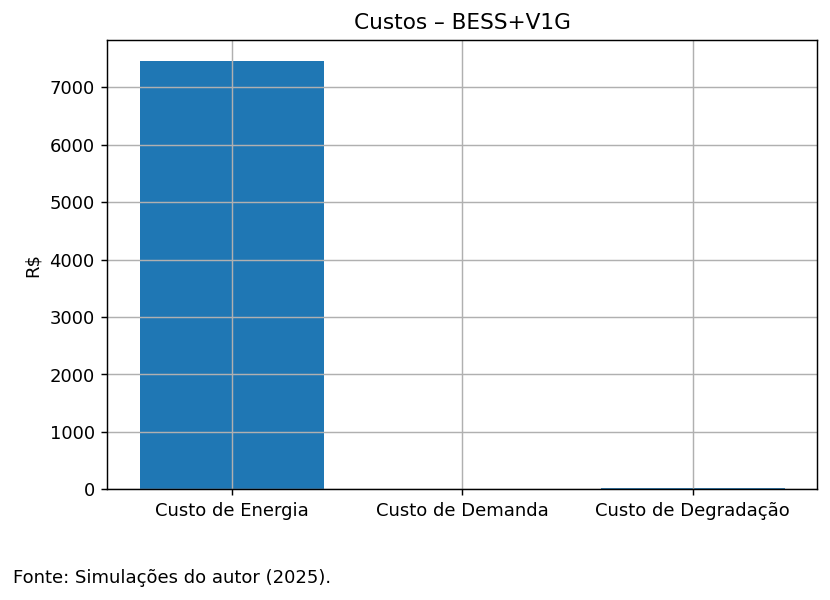

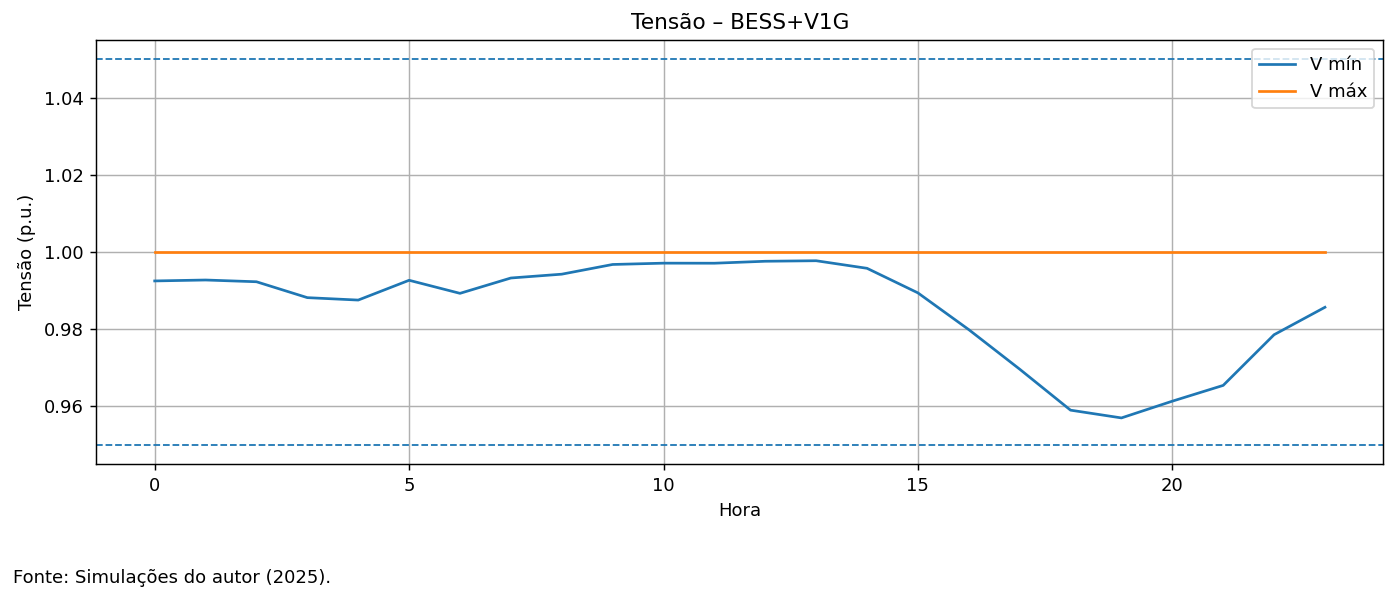

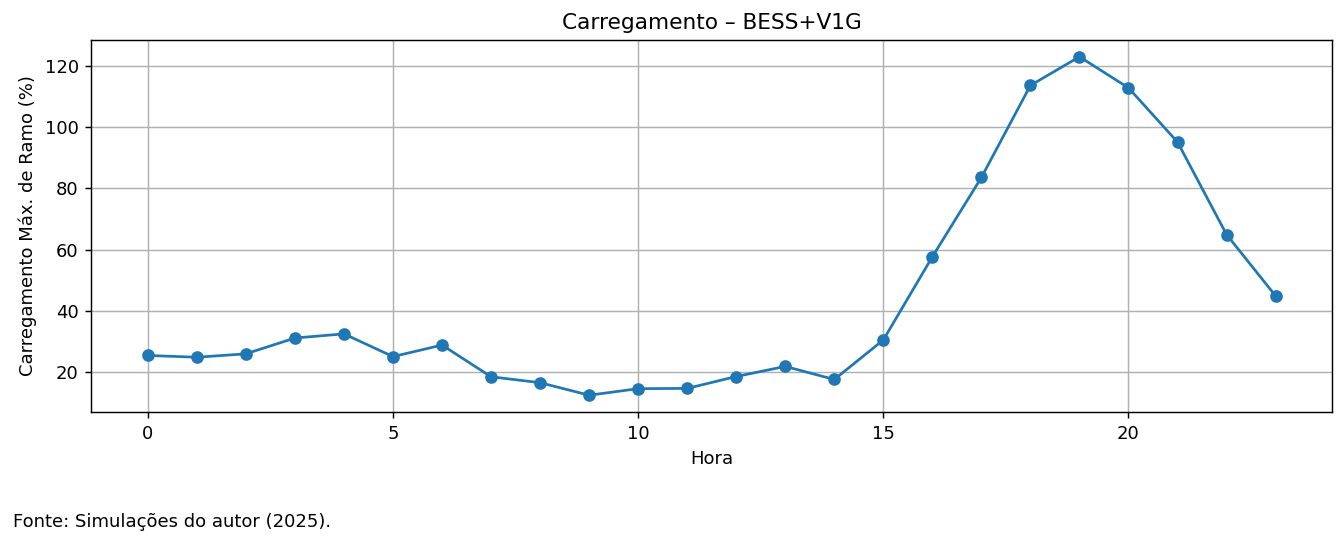

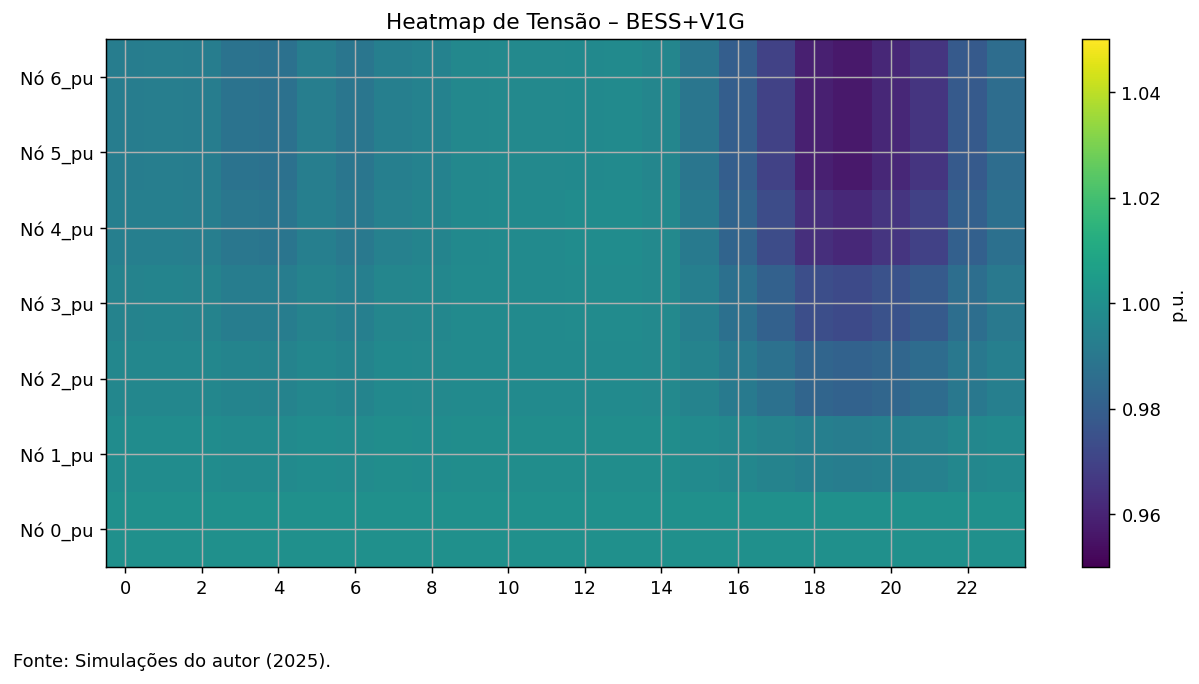

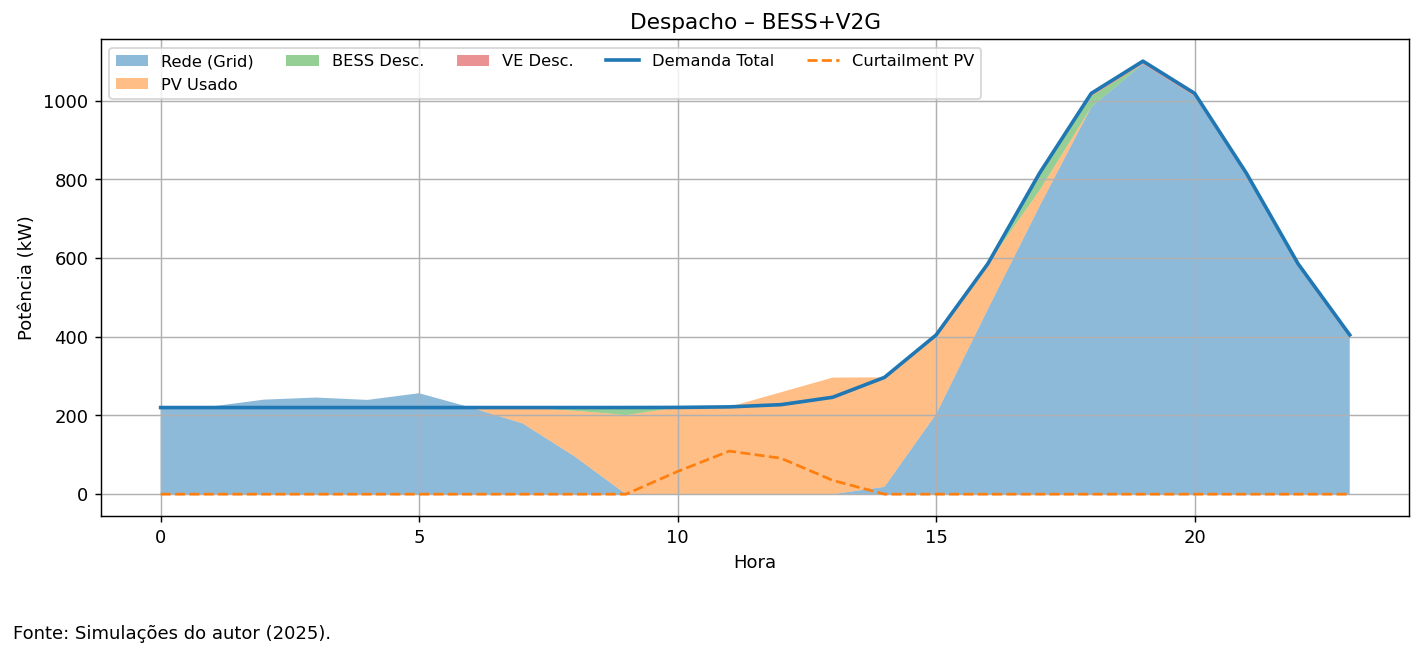

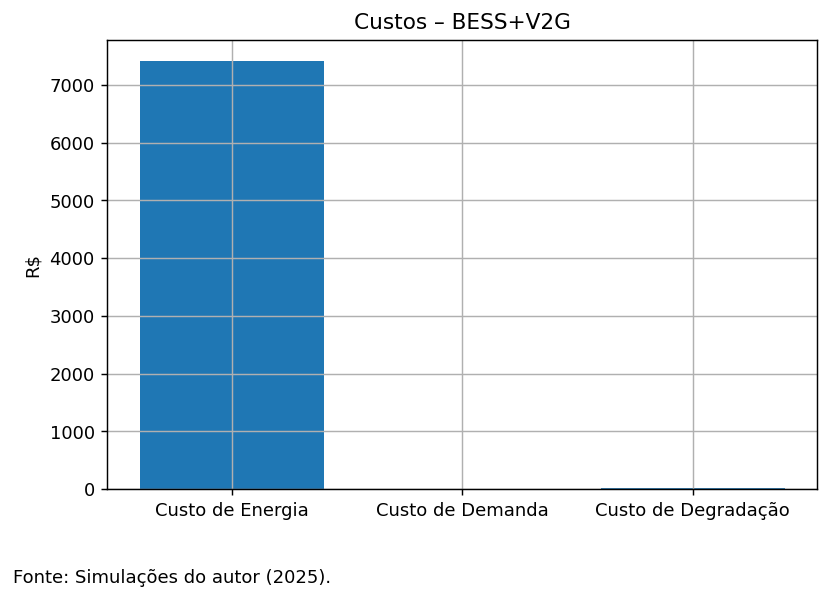

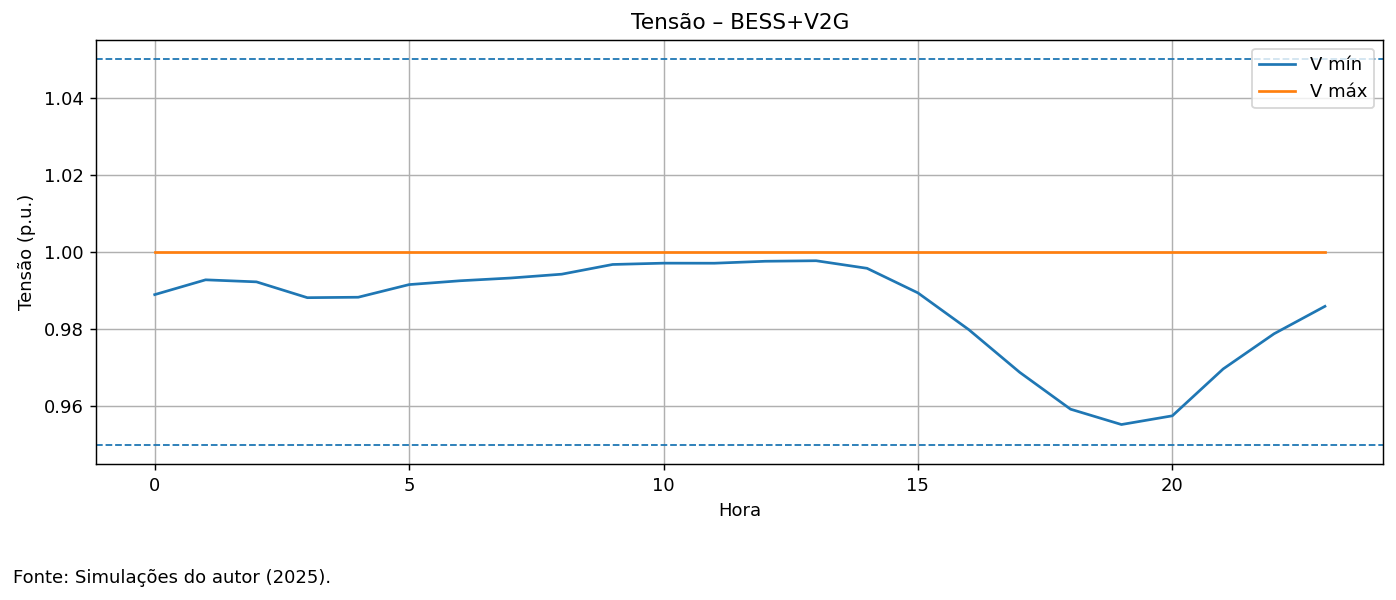

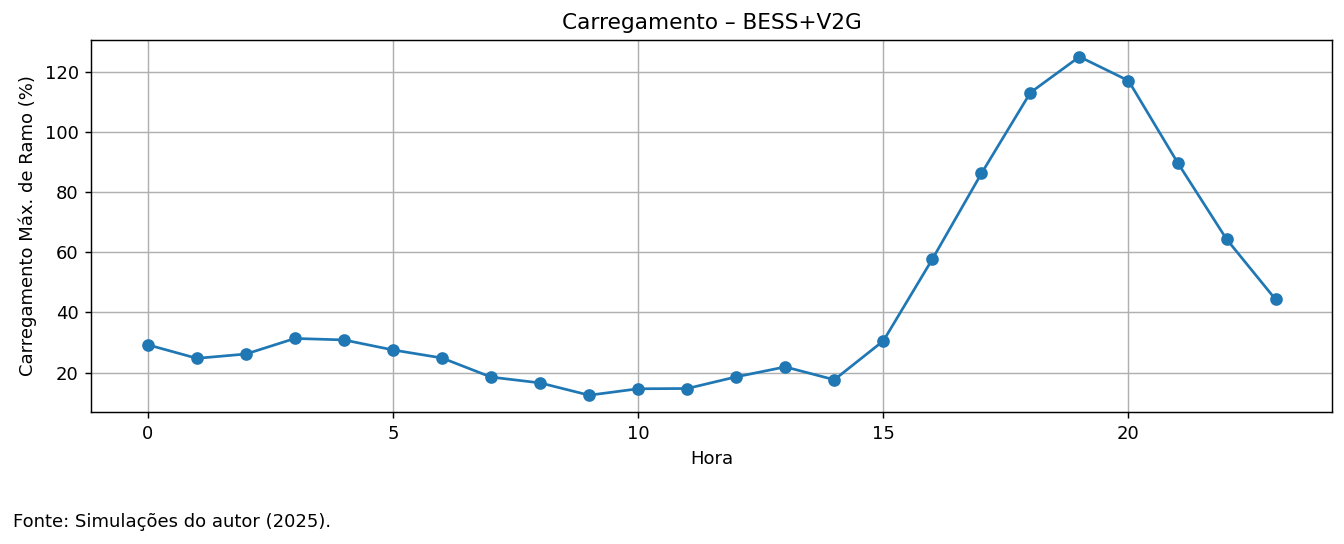

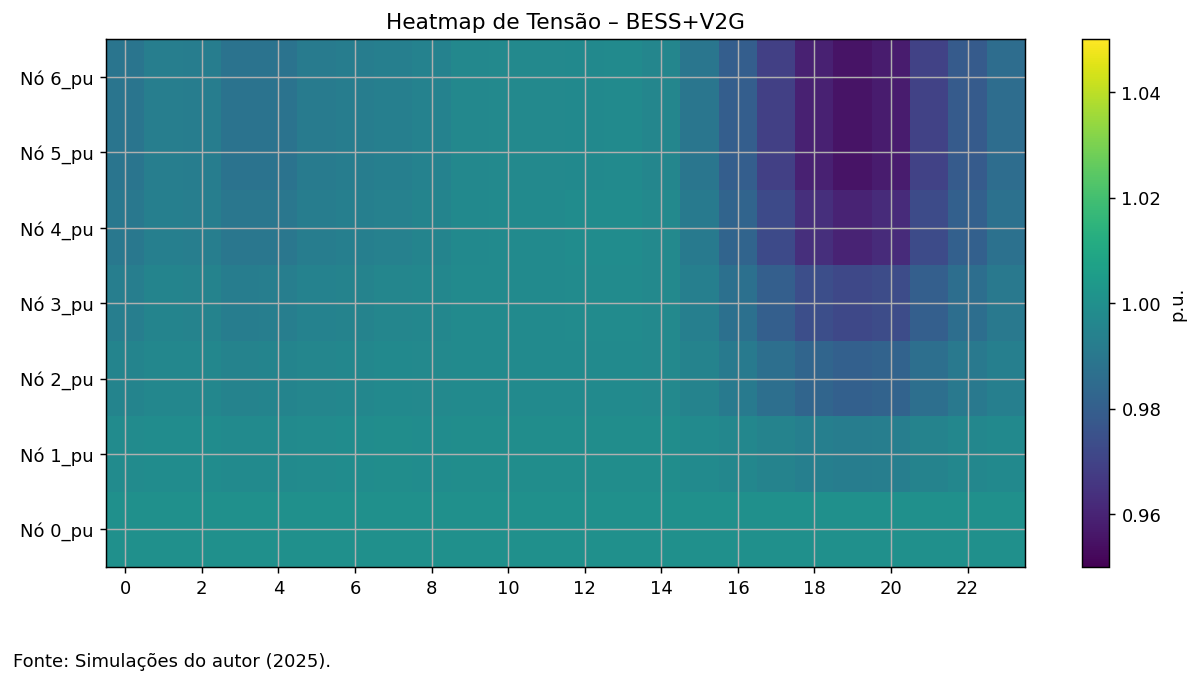

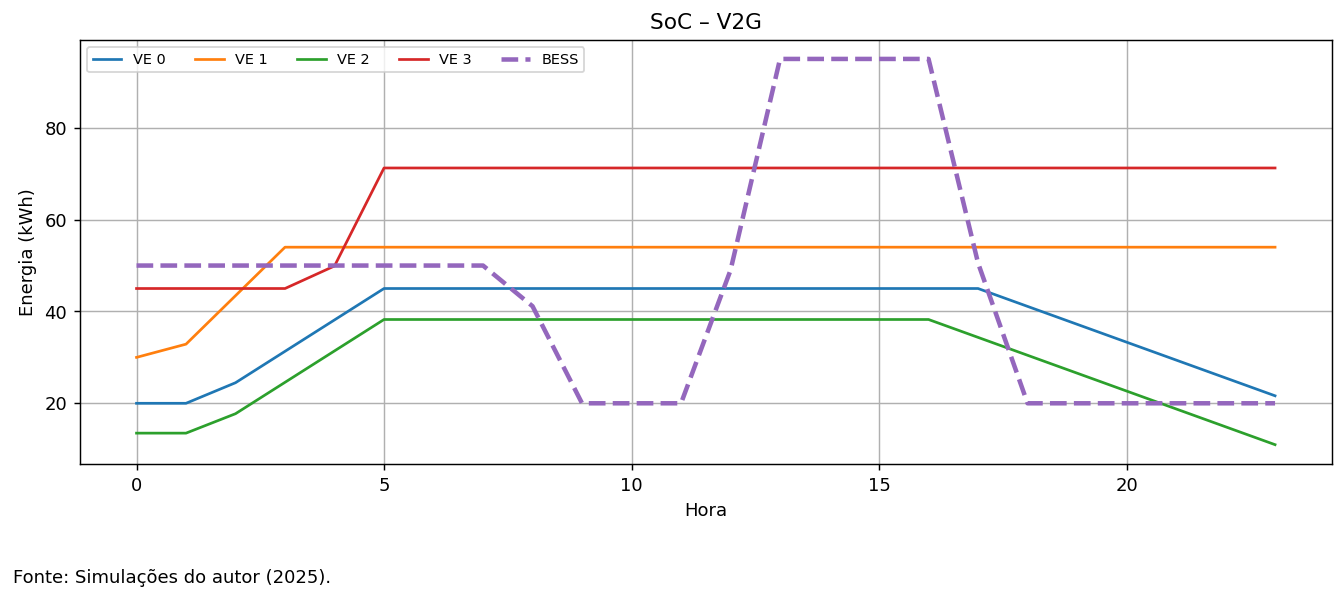

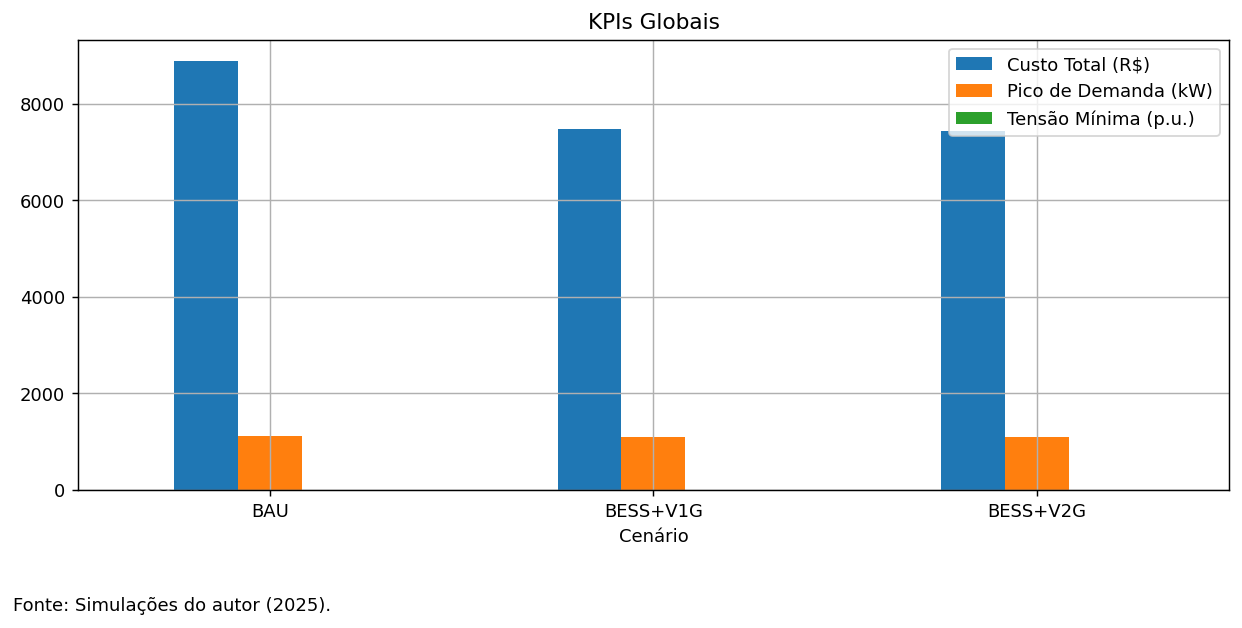


Figuras salvas em /content/figs
CSV de KPIs (BR): /content/figs/kpi_comparativo_BR.csv
Markdown de KPIs: /content/figs/kpi_comparativo_BR.md

--- Concluído ---


In [6]:
# =========================================
# Colab-ready: BAU, BESS+V1G, BESS+V2G (com Volt/VAR), KPIs + Figuras + Tabela 4.1 (BR)
# =========================================
!apt-get -y -qq install coinor-cbc >/dev/null
%pip -q install pyomo

import os, math, shutil
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo

plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.grid'] = True
print("Ambiente pronto.")

# ============================ PARÂMETROS GERAIS ============================
GENERAL = {
    'BESS_E_CAP_KWH'          : 100.0,
    'BESS_P_CH_MAX_KW'        : 50.0,
    'BESS_P_DIS_MAX_KW'       : 40.0,
    'BESS_ETA_CH'             : 0.92,
    'BESS_ETA_DIS'            : 0.90,
    'BESS_SOC_MIN_PU'         : 0.20,
    'BESS_SOC_MAX_PU'         : 0.95,
    'BESS_SOC_INIT_PU'        : 0.50,
    'CDEG_BESS_R_PER_KWH'     : 0.10,
    'CDEG_EV_R_PER_KWH'       : 0.05,
    'C_CURTAILMENT_R_PER_KWH' : 0.02,
    'C_PICO_R_PER_KW'         : 0.0,     # deixe 0.0 se quiser ignorar custo de demanda
    'DELTA_T_H'               : 1.0,
    'V_MIN_PU'                : 0.95,
    'V_MAX_PU'                : 1.05,
    'V_REF_PU'                : 1.00,
    'PF_CARGA'                : 0.95,
    'V_LL_BASE_kV'            : 13.8,
    'S_BASE_kVA'              : 1000.0,
    'BESS_NODE'               : 2,
    'PV_NODE'                 : 4,
}

# ============================ DADOS EMBUTIDOS (1100 kW) ============================
T = list(range(24))

# Tarifa com ponta ~18-21h
tarifa = np.array(
 [0.60,0.60,0.60,0.60,0.60,0.60,0.70,0.80,0.90,1.00,1.10,1.10,
  1.00,0.90,0.80,0.70,0.60,1.20,1.20,1.20,1.20,0.70,0.60,0.60], dtype=float)
C_ENERGIA = {t: float(tarifa[t]) for t in T}

# Carga ativa (pico ≈ 1100 kW às 19h) distribuída em nós 2,4,5
t_arr = np.arange(24)
shape = 0.20 + 0.80*np.exp(-((t_arr-19.0)/3.2)**2)
shape = shape / shape.max()
P_total = 1100.0*shape
fractions = {'no_2_kw':0.40, 'no_4_kw':0.35, 'no_5_kw':0.25}
LOAD = pd.DataFrame({'hora': T})
for col, frac in fractions.items():
    LOAD[col] = P_total*frac

# PV no nó 4 (pico ~350 kW ao meio-dia)
pv = np.maximum(0.0, np.sin(np.pi*(t_arr-6)/12.0))**1.6
pv = pv / pv.max() * 350.0
PV = pd.DataFrame({'hora': T, 'pv_kw_4': pv})

# Frota de VEs (4 veículos; 2 com V2G habilitado)
EV = pd.DataFrame([
    [0, 50,  7.2,  3.7, 0.95, 0.95, 18, 7, 0.40, 0.90, 1, 4],
    [1, 60, 11.0,  5.0, 0.96, 0.94, 19, 8, 0.50, 0.90, 0, 4],
    [2, 45,  7.2,  3.7, 0.95, 0.95, 17, 6, 0.30, 0.85, 1, 5],
    [3, 75, 22.0, 11.0, 0.97, 0.96, 20, 7, 0.60, 0.95, 0, 5]
], columns=['id','cap_kwh','p_ch_kw','p_dis_kw','eta_ch','eta_dis','t_in','t_out','soc_ini_pu','soc_target_pu','v2g','node'])

# Rede radial (parâmetros em p.u. sobre S_base e V_ll_base; limites em kW)
NET = pd.DataFrame([
    [0, 1, 0.004, 0.008, 1500],
    [1, 2, 0.006, 0.012, 1200],
    [2, 3, 0.008, 0.016, 1000],
    [3, 4, 0.010, 0.020,  900],
    [4, 5, 0.010, 0.020,  800],
    [5, 6, 0.010, 0.020,  700]
], columns=['from_node','to_node','r_pu','x_pu','p_max_kw'])

# ============================ DERIVADOS E DICIONÁRIOS ============================
DELTA_T_H     = GENERAL['DELTA_T_H']
BESS_E_CAP    = GENERAL['BESS_E_CAP_KWH']
BESS_P_CH_MAX = GENERAL['BESS_P_CH_MAX_KW']
BESS_P_DIS_MAX= GENERAL['BESS_P_DIS_MAX_KW']
BESS_ETA_CH   = GENERAL['BESS_ETA_CH']
BESS_ETA_DIS  = GENERAL['BESS_ETA_DIS']
BESS_SOC_MIN  = GENERAL['BESS_SOC_MIN_PU']
BESS_SOC_MAX  = GENERAL['BESS_SOC_MAX_PU']
BESS_SOC_INIT = GENERAL['BESS_SOC_INIT_PU']
C_DEG_BESS    = GENERAL['CDEG_BESS_R_PER_KWH']
C_DEG_EV      = GENERAL['CDEG_EV_R_PER_KWH']
C_CURT        = GENERAL['C_CURTAILMENT_R_PER_KWH']
C_PICO        = GENERAL['C_PICO_R_PER_KW']
V_MIN_PU      = GENERAL['V_MIN_PU']
V_MAX_PU      = GENERAL['V_MAX_PU']
V_REF_PU      = GENERAL['V_REF_PU']
PF_CARGA      = GENERAL['PF_CARGA']
S_BASE_kW     = GENERAL['S_BASE_kVA']
BESS_NODE     = GENERAL['BESS_NODE']
PV_NODE       = GENERAL['PV_NODE']

# Carga ativa por nó/hora
load_cols = [c for c in LOAD.columns if c != 'hora']
node_from_col = {c: int(c.split('_')[1]) for c in load_cols}  # no_2_kw -> 2
P_carga = {}
for _, row in LOAD.iterrows():
    hr = int(row['hora'])
    for c, node in node_from_col.items():
        P_carga[(node, hr)] = float(row[c])

# PV por nó/hora
P_pv = {(PV_NODE, int(r['hora'])): float(r['pv_kw_4']) for _, r in PV.iterrows()}

# VE dicts
V = sorted(EV['id'].astype(int).tolist())
Emax_VE           = {int(r.id): float(r.cap_kwh) for _, r in EV.iterrows()}
Pmax_ch_VE        = {int(r.id): float(r.p_ch_kw) for _, r in EV.iterrows()}
Pmax_dis_VE       = {int(r.id): float(r.p_dis_kw) for _, r in EV.iterrows()}
eta_ch_VE         = {int(r.id): float(r.eta_ch)  for _, r in EV.iterrows()}
eta_dis_VE        = {int(r.id): float(r.eta_dis) for _, r in EV.iterrows()}
t_in_VE           = {int(r.id): int(r.t_in)      for _, r in EV.iterrows()}
t_out_VE          = {int(r.id): int(r.t_out)     for _, r in EV.iterrows()}
SoC_init_VE_kwh   = {int(r.id): float(r.cap_kwh)*float(r.soc_ini_pu)    for _, r in EV.iterrows()}
SoC_target_VE_kwh = {int(r.id): float(r.cap_kwh)*float(r.soc_target_pu) for _, r in EV.iterrows()}
v2g_flag          = {int(r.id): int(r.v2g)       for _, r in EV.iterrows()}
VE_nodes          = {int(r.id): int(r.node)      for _, r in EV.iterrows()}

# Disponibilidade (1 se presente; janela pode cruzar meia-noite)
def available(i, t):
    ti, to = t_in_VE[i], t_out_VE[i]
    if ti > to:
        return 1 if (t >= ti or t < to) else 0
    return 1 if (ti <= t < to) else 0

a_disp_VE = {(i,t): available(i,t) for i in V for t in T}

# Rede
E_branches = [(int(r.from_node), int(r.to_node)) for _, r in NET.iterrows()]
N_nodes = sorted(set([i for i,_ in E_branches] + [j for _,j in E_branches] + [n for (n,_) in P_carga.keys()]))
R_pu = {(int(r.from_node), int(r.to_node)): float(r.r_pu) for _, r in NET.iterrows()}
X_pu = {(int(r.from_node), int(r.to_node)): float(r.x_pu) for _, r in NET.iterrows()}
S_max_ramo_kw = {(int(r.from_node), int(r.to_node)): float(r.p_max_kw) for _, r in NET.iterrows()}

children_of = {n: [] for n in N_nodes}
parent_of = {}
for (i,j) in E_branches:
    children_of[i].append(j)
    parent_of[j] = i
SLACK = min([i for i,_ in E_branches])

# Q de carga via PF
phi = math.acos(max(min(PF_CARGA,1.0),-1.0))
tanphi = math.tan(phi)
Q_carga = {(j,t): P_carga.get((j,t),0.0)*tanphi for j in N_nodes for t in T}

# Limites de Q (Volt/VAR) BESS/VE (~60% P_max)
BESS_Q_MAX_kVar = 0.6 * max(BESS_P_CH_MAX, BESS_P_DIS_MAX)
Smax_VE = {i: max(Pmax_ch_VE[i], Pmax_dis_VE[i]) for i in V}
Qmax_VE = {i: 0.6*Smax_VE[i] for i in V}

print(f"Pico da carga agregada às 19h: {sum(P_carga.get((j,19),0) for j in N_nodes):.1f} kW")
print(f"Nós da rede: {N_nodes} | SLACK: {SLACK}")

# ============================ MODELO (Pyomo) ============================
Tlist = list(T)
prev_t = {Tlist[i]: Tlist[i-1] for i in range(len(Tlist))}

def run_optimization_scenario(v2g_enabled: bool, bess_present: bool):
    m = pyo.ConcreteModel()
    m.T = pyo.Set(initialize=Tlist)
    m.N = pyo.Set(initialize=N_nodes)
    m.VE= pyo.Set(initialize=V)
    m.E = pyo.Set(initialize=E_branches, dimen=2)

    # Variáveis
    m.P_grid = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_max_pico = pyo.Var(domain=pyo.NonNegativeReals)
    m.P_curt = pyo.Var(m.N, m.T, domain=pyo.NonNegativeReals)

    m.P_bess_ch = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_bess_dis= pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.Q_bess_inj= pyo.Var(m.T, domain=pyo.Reals)
    m.SoC_BESS  = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.u_BESS    = pyo.Var(m.T, domain=pyo.Binary)

    m.P_ve_ch   = pyo.Var(m.VE, m.T, domain=pyo.NonNegativeReals)
    m.P_ve_dis  = pyo.Var(m.VE, m.T, domain=pyo.NonNegativeReals)
    m.Q_ve_inj  = pyo.Var(m.VE, m.T, domain=pyo.Reals)
    m.SoC_VE    = pyo.Var(m.VE, m.T, domain=pyo.NonNegativeReals)
    m.u_VE      = pyo.Var(m.VE, m.T, domain=pyo.Binary)

    m.P_ramo    = pyo.Var(m.E, m.T, domain=pyo.Reals)
    m.Q_ramo    = pyo.Var(m.E, m.T, domain=pyo.Reals)
    m.Q_grid    = pyo.Var(m.T, domain=pyo.Reals)
    m.V2        = pyo.Var(m.N, m.T, domain=pyo.NonNegativeReals)

    # Objetivo
    def obj(m):
        c_energia = sum(C_ENERGIA[t]*m.P_grid[t]*DELTA_T_H for t in m.T)
        c_pico    = C_PICO * m.P_max_pico
        c_curt    = sum(C_CURT * m.P_curt[j,t]*DELTA_T_H for j in m.N for t in m.T)
        c_deg_b   = (sum(C_DEG_BESS*(m.P_bess_ch[t]+m.P_bess_dis[t])*DELTA_T_H for t in m.T) if bess_present else 0.0)
        c_deg_ev  = sum(C_DEG_EV*(m.P_ve_ch[i,t]+m.P_ve_dis[i,t])*DELTA_T_H for i in m.VE for t in m.T)
        return c_energia + c_pico + c_curt + c_deg_b + c_deg_ev
    m.OBJ = pyo.Objective(rule=obj, sense=pyo.minimize)

    # Restrições
    m.P_grid_peak = pyo.Constraint(m.T, rule=lambda m,t: m.P_grid[t] <= m.P_max_pico)
    m.curt_limit  = pyo.Constraint(m.N, m.T, rule=lambda m,j,t: m.P_curt[j,t] <= P_pv.get((j,t), 0.0))

    # BESS
    if bess_present:
        SoC_min = BESS_SOC_MIN * BESS_E_CAP
        SoC_max = BESS_SOC_MAX * BESS_E_CAP
        SoC_ini = BESS_SOC_INIT * BESS_E_CAP
        def bess_soc(m, t):
            tp = prev_t[t]
            s_prev = SoC_ini if t==Tlist[0] else m.SoC_BESS[tp]
            return m.SoC_BESS[t] == s_prev + (m.P_bess_ch[t]*BESS_ETA_CH - m.P_bess_dis[t]/BESS_ETA_DIS)*DELTA_T_H
        m.BESS_SoC = pyo.Constraint(m.T, rule=bess_soc)
        m.BESS_box = pyo.Constraint(m.T, rule=lambda m,t: pyo.inequality(SoC_min, m.SoC_BESS[t], SoC_max))
        m.BESS_p_ch= pyo.Constraint(m.T, rule=lambda m,t: m.P_bess_ch[t] <= BESS_P_CH_MAX*m.u_BESS[t])
        m.BESS_p_ds= pyo.Constraint(m.T, rule=lambda m,t: m.P_bess_dis[t] <= BESS_P_DIS_MAX*(1 - m.u_BESS[t]))
        m.BESS_Q_limit = pyo.Constraint(m.T, rule=lambda m,t: pyo.inequality(-BESS_Q_MAX_kVar, m.Q_bess_inj[t], BESS_Q_MAX_kVar))
    else:
        m.BESS_zero_P = pyo.Constraint(m.T, rule=lambda m,t: m.P_bess_ch[t] + m.P_bess_dis[t] == 0)
        m.BESS_zero_Q = pyo.Constraint(m.T, rule=lambda m,t: m.Q_bess_inj[t] == 0)

    # VEs
    def ve_soc(m, i, t):
        tp = prev_t[t]
        s_prev = SoC_init_VE_kwh[i] if t==Tlist[0] else m.SoC_VE[i, tp]
        return m.SoC_VE[i,t] == s_prev + (m.P_ve_ch[i,t]*eta_ch_VE[i] - m.P_ve_dis[i,t]/eta_dis_VE[i])*DELTA_T_H
    m.VE_SoC = pyo.Constraint(m.VE, m.T, rule=ve_soc)
    m.VE_ch_lim = pyo.Constraint(m.VE, m.T, rule=lambda m,i,t: m.P_ve_ch[i,t]  <= Pmax_ch_VE[i]*a_disp_VE[(i,t)]*m.u_VE[i,t])
    m.VE_ds_lim = pyo.Constraint(m.VE, m.T, rule=lambda m,i,t: m.P_ve_dis[i,t] <= Pmax_dis_VE[i]*a_disp_VE[(i,t)]*((v2g_flag[i] if v2g_enabled else 0))*(1 - m.u_VE[i,t]))
    m.VE_Q_limit = pyo.Constraint(m.VE, m.T, rule=lambda m,i,t: pyo.inequality(-Qmax_VE[i]*a_disp_VE[(i,t)], m.Q_ve_inj[i,t], Qmax_VE[i]*a_disp_VE[(i,t)]))

    def ve_target(m, i):
        tidx  = (t_out_VE[i] - 1) % len(Tlist)
        t_hour = Tlist[tidx]
        return m.SoC_VE[i, t_hour] >= SoC_target_VE_kwh[i]
    m.VE_target = pyo.Constraint(m.VE, rule=ve_target)

    # Balanço de P (radial)
    def bal_P(m, j, t):
        if j == SLACK:
            return m.P_grid[t] == sum(m.P_ramo[i,k,t] for (i,k) in m.E if i==SLACK)
        parent = parent_of.get(j, None)
        if parent is None: return pyo.Constraint.Skip
        inflow   = m.P_ramo[parent, j, t]
        outflow  = sum(m.P_ramo[j,k,t] for k in children_of.get(j, []))
        inj_pv   = P_pv.get((j,t),0.0) - m.P_curt[j,t]
        inj_bess = (m.P_bess_dis[t] - m.P_bess_ch[t]) if (j==BESS_NODE and bess_present) else 0.0
        inj_ve   = sum(m.P_ve_dis[i,t] - m.P_ve_ch[i,t] for i in m.VE if VE_nodes[i]==j)
        carga    = P_carga.get((j,t),0.0)
        return inflow - outflow == carga - (inj_pv + inj_bess + inj_ve)
    m.BAL_P = pyo.Constraint(m.N, m.T, rule=bal_P)

    # Balanço de Q
    def bal_Q(m, j, t):
        if j == SLACK:
            return m.Q_grid[t] == sum(m.Q_ramo[i,k,t] for (i,k) in m.E if i==SLACK)
        parent = parent_of.get(j, None)
        if parent is None: return pyo.Constraint.Skip
        inflow  = m.Q_ramo[parent, j, t]
        outflow = sum(m.Q_ramo[j,k,t] for k in children_of.get(j, []))
        q_carga = Q_carga.get((j,t), 0.0)
        inj_Q_bess = m.Q_bess_inj[t] if (j == BESS_NODE and bess_present) else 0.0
        inj_Q_ves  = sum(m.Q_ve_inj[i,t] for i in m.VE if VE_nodes[i] == j)
        inj_Q      = inj_Q_bess + inj_Q_ves
        return inflow - outflow == q_carga - inj_Q
    m.BAL_Q = pyo.Constraint(m.N, m.T, rule=bal_Q)

    # Queda de tensão (LinDistFlow)
    @m.Constraint(m.E, m.T)
    def V_drop(m, i, j, t):
        p_pu = m.P_ramo[i,j,t] / S_BASE_kW
        q_pu = m.Q_ramo[i,j,t] / S_BASE_kW
        return m.V2[j,t] == m.V2[i,t] - 2.0*(R_pu[(i,j)]*p_pu + X_pu[(i,j)]*q_pu)

    # Tensão do slack
    def slack_v(m, t):
        return m.V2[SLACK, t] == V_REF_PU**2
    m.V_slack  = pyo.Constraint(m.T, rule=slack_v)

    Vmin2, Vmax2 = V_MIN_PU**2, V_MAX_PU**2
    m.V_limits = pyo.Constraint(m.N, m.T, rule=lambda m,j,t: pyo.inequality(Vmin2, m.V2[j,t], Vmax2) if j!= SLACK else pyo.Constraint.Skip)

    # Limites de ramo (caixa)
    m.P_box = pyo.Constraint(m.E, m.T, rule=lambda m,i,j,t: pyo.inequality(-S_max_ramo_kw[(i,j)], m.P_ramo[i,j,t], S_max_ramo_kw[(i,j)]))
    m.Q_box = pyo.Constraint(m.E, m.T, rule=lambda m,i,j,t: pyo.inequality(-S_max_ramo_kw[(i,j)], m.Q_ramo[i,j,t], S_max_ramo_kw[(i,j)]))

    solver = pyo.SolverFactory('cbc') if shutil.which('cbc') else pyo.SolverFactory('glpk')
    res = solver.solve(m, tee=False)
    return res, m

# ============================ BAU (analítico simples) ============================
def simulate_bau():
    df = pd.DataFrame(index=T); df.index.name='hora'
    # VE carrega no máximo quando presente
    P_ve_ch_nodal = {(j,t):0.0 for j in N_nodes for t in T}
    for i in V:
        node = VE_nodes[i]
        for tt in T:
            if a_disp_VE[(i,tt)]==1:
                P_ve_ch_nodal[(node,tt)] += Pmax_ch_VE[i]

    # Fluxos P/Q por agregação bottom-up
    P_ramo = {}; Q_ramo = {}
    for (i,j) in E_branches:
        for tt in T:
            P_ramo[(i,j,tt)] = 0.0
            Q_ramo[(i,j,tt)] = 0.0

    for tt in T:
        netP = {j: max(0.0, P_carga.get((j,tt),0.0) - P_pv.get((j,tt),0.0) + P_ve_ch_nodal.get((j,tt),0.0)) for j in N_nodes}
        netQ = {j: Q_carga.get((j,tt),0.0) for j in N_nodes}
        for j in sorted(N_nodes, reverse=True):
            if j==SLACK: continue
            i = parent_of.get(j, None)
            if i is None: continue
            P_ramo[(i,j,tt)] = netP.get(j,0.0) + sum(P_ramo.get((j,k,tt),0.0) for k in children_of.get(j, []))
            Q_ramo[(i,j,tt)] = netQ.get(j,0.0) + sum(Q_ramo.get((j,k,tt),0.0) for k in children_of.get(j, []))

    V2 = {(SLACK,tt): V_REF_PU**2 for tt in T}
    for tt in T:
        q = deque(children_of[SLACK])
        while q:
            j = q.popleft()
            i = parent_of[j]
            p_pu = P_ramo[(i,j,tt)]/S_BASE_kW
            q_pu = Q_ramo[(i,j,tt)]/S_BASE_kW
            V2[(j,tt)] = V2[(i,tt)] - 2.0*(R_pu[(i,j)]*p_pu + X_pu[(i,j)]*q_pu)
            for k in children_of[j]: q.append(k)

    df['P_grid_kW']        = [sum(P_ramo.get((SLACK,k,tt),0.0) for k in children_of[SLACK]) for tt in T]
    df['P_grid_kW']        = df['P_grid_kW'].clip(lower=0.0)
    df['P_carga_total_kW'] = [sum(P_carga.get((j,tt),0.0) for j in N_nodes) for tt in T]
    df['P_pv_total_kW']    = [sum(P_pv.get((j,tt),0.0) for j in N_nodes) for tt in T]
    df['P_ve_ch_total_kW'] = [sum(P_ve_ch_nodal.get((j,tt),0.0) for j in N_nodes) for tt in T]
    df['P_ve_dis_total_kW']= 0.0
    df['P_curt_total_kW']  = 0.0
    for j in N_nodes:
        df[f'V_no_{j}_pu'] = [math.sqrt(max(V2.get((j,tt), V_REF_PU**2), 0.0)) for tt in T]

    # KPIs
    pico = float(df['P_grid_kW'].max())
    c_energia = float(sum(C_ENERGIA[t]*df.loc[t,'P_grid_kW']*DELTA_T_H for t in T))
    c_pico    = float(C_PICO*pico)
    c_deg     = float(sum(C_DEG_EV*df.loc[t,'P_ve_ch_total_kW']*DELTA_T_H for t in T))
    kpis = {
        'Custo de Energia': c_energia,
        'Custo de Demanda': c_pico,
        'Custo de Degradação': c_deg,
        'Energia Importada (kWh)': float(df['P_grid_kW'].sum()*DELTA_T_H),
        'Energia PV Curtailada (kWh)': 0.0,
        'Pico de Demanda (kW)': pico,
        'Tensão Mínima (p.u.)': float(df[[c for c in df.columns if c.startswith('V_no_')]].min().min())
    }

    det = {
        'ramoP_df': pd.DataFrame({f'{i}-{j}': [P_ramo.get((i,j,tt),0.0) for tt in T] for (i,j) in E_branches}, index=T),
        'ramoQ_df': pd.DataFrame({f'{i}-{j}': [Q_ramo.get((i,j,tt),0.0) for tt in T] for (i,j) in E_branches}, index=T),
        'soc_ve': {}
    }
    # SoC ve (carregamento ingênuo)
    for i in V:
        soc = np.zeros(len(T), dtype=float)
        soc[0] = SoC_init_VE_kwh[i]
        for tt in range(1,len(T)):
            p_ch = (Pmax_ch_VE[i] if a_disp_VE[(i,tt)]==1 else 0.0)
            soc[tt] = min(Emax_VE[i], soc[tt-1] + p_ch*eta_ch_VE[i]*DELTA_T_H)
        det['soc_ve'][i] = soc
    return df, kpis, det

# ============================ EXECUÇÃO ============================
results_repo = {}
print("Executando: BAU ...")
bau_agg, bau_kpis, bau_det = simulate_bau()
results_repo['BAU'] = {'agregado': bau_agg, 'kpis': bau_kpis, 'detalhado': bau_det}

scenarios_opt = {'BESS+V1G': {'v2g': False, 'bess': True},
                 'BESS+V2G': {'v2g': True,  'bess': True}}

for name, cfg in scenarios_opt.items():
    print(f"Executando: {name} ...")
    res, m = run_optimization_scenario(v2g_enabled=cfg['v2g'], bess_present=cfg['bess'])
    agg = pd.DataFrame(index=T); agg.index.name='hora'
    agg['P_grid_kW']         = [pyo.value(m.P_grid[t]) for t in T]
    agg['P_carga_total_kW']  = [sum(P_carga.get((j,t),0.0) for j in N_nodes) for t in T]
    agg['P_pv_total_kW']     = [sum(P_pv.get((j,t),0.0) for j in N_nodes) for t in T]
    agg['P_curt_total_kW']   = [sum(pyo.value(m.P_curt[j,t]) for j in N_nodes) for t in T]
    agg['P_bess_ch_kW']      = [pyo.value(m.P_bess_ch[t]) if cfg['bess'] else 0.0 for t in T]
    agg['P_bess_dis_kW']     = [pyo.value(m.P_bess_dis[t]) if cfg['bess'] else 0.0 for t in T]
    agg['P_ve_ch_total_kW']  = [sum(pyo.value(m.P_ve_ch[i,t]) for i in V) for t in T]
    agg['P_ve_dis_total_kW'] = [sum(pyo.value(m.P_ve_dis[i,t]) for i in V) for t in T]
    for j in N_nodes:
        agg[f'V_no_{j}_pu'] = [math.sqrt(max(pyo.value(m.V2[j,t]), 0.0)) for t in T]

    custos = {
        'Custo de Energia': float(sum(C_ENERGIA[t]*pyo.value(m.P_grid[t])*DELTA_T_H for t in T)),
        'Custo de Demanda': float(C_PICO * pyo.value(m.P_max_pico)),
        'Custo de Degradação': float(
            (sum(C_DEG_BESS*(pyo.value(m.P_bess_ch[t])+pyo.value(m.P_bess_dis[t]))*DELTA_T_H for t in T) if cfg['bess'] else 0.0)
            + sum(C_DEG_EV*(pyo.value(m.P_ve_ch[i,t])+pyo.value(m.P_ve_dis[i,t]))*DELTA_T_H for i in V for t in T)
        ),
        'Energia Importada (kWh)': float(sum(pyo.value(m.P_grid[t])*DELTA_T_H for t in T)),
        'Energia PV Curtailada (kWh)': float(sum(agg['P_curt_total_kW'])*DELTA_T_H),
        'Pico de Demanda (kW)': float(max(agg['P_grid_kW'])),
        'Tensão Mínima (p.u.)': float(agg[[c for c in agg.columns if c.startswith('V_no_')]].min().min())
    }

    # SoC (para V2G)
    soc_ves = {i: [pyo.value(m.SoC_VE[i,t]) for t in T] for i in V}
    soc_bess = [pyo.value(m.SoC_BESS[t]) for t in T] if cfg['bess'] else None

    results_repo[name] = {'agregado': agg, 'kpis': custos, 'detalhado': {
        'ramoP_df': pd.DataFrame({f'{i}-{j}': [pyo.value(m.P_ramo[i,j,t]) for t in T] for (i,j) in E_branches}, index=T),
        'ramoQ_df': pd.DataFrame({f'{i}-{j}': [pyo.value(m.Q_ramo[i,j,t]) for t in T] for (i,j) in E_branches}, index=T),
        'soc_ve': soc_ves,
        'soc_bess': soc_bess
    }}

print("Cenários executados.")

# ============================ KPIs & SUMÁRIO ============================
summary_rows = []
for scen in ['BAU','BESS+V1G','BESS+V2G']:
    agg  = results_repo[scen]['agregado']
    kpis = results_repo[scen]['kpis']
    summary_rows.append({
        'Cenário': scen,
        'Custo Total (R$)': kpis.get('Custo de Energia',0.0)+kpis.get('Custo de Demanda',0.0)+kpis.get('Custo de Degradação',0.0),
        'Custo de Energia (R$)': kpis.get('Custo de Energia',0.0),
        'Custo de Demanda (R$)': kpis.get('Custo de Demanda',0.0),
        'Custo de Degradação (R$)': kpis.get('Custo de Degradação',0.0),
        'Pico de Demanda (kW)': kpis.get('Pico de Demanda (kW)', float(agg['P_grid_kW'].max())),
        'Energia Importada (kWh)': kpis.get('Energia Importada (kWh)', float(agg['P_grid_kW'].sum()*DELTA_T_H)),
        'Energia PV Curtailada (kWh)': kpis.get('Energia PV Curtailada (kWh)', 0.0),
        'Tensão Mínima (p.u.)': kpis.get('Tensão Mínima (p.u.)', float(agg[[c for c in agg.columns if c.startswith('V_no_')]].min().min()))
    })
summary = pd.DataFrame(summary_rows).set_index('Cenário')

if 'BAU' in summary.index:
    bau = summary.loc['BAU']
    summary['Redução Custo Total (%)'] = (1 - summary['Custo Total (R$)']/bau['Custo Total (R$)'])*100
    summary['Redução Pico Demanda (%)'] = (1 - summary['Pico de Demanda (kW)']/bau['Pico de Demanda (kW)'])*100

print("\n--- KPIs (numéricos crus) ---")
print(summary)

# ============================ FORMATAÇÃO BR + IMPRESSÃO ABNT (Tabela 4.1) ============================
def fmt_br(x, nd=2):
    try:
        if x is None or (isinstance(x, float) and (math.isnan(x) or math.isinf(x))):
            return ""
        s = f"{float(x):,.{nd}f}"
        return s.replace(",", "X").replace(".", ",").replace("X", ".")
    except Exception:
        return str(x)

cols_order = [
    'Custo Total (R$)',
    'Custo de Energia (R$)',
    'Custo de Demanda (R$)',
    'Custo de Degradação (R$)',
    'Pico de Demanda (kW)',
    'Energia Importada (kWh)',
    'Energia PV Curtailada (kWh)',
    'Tensão Mínima (p.u.)',
    'Redução Custo Total (%)',
    'Redução Pico Demanda (%)'
]
for c in cols_order:
    if c not in summary.columns:
        summary[c] = np.nan
summary = summary[cols_order]

# Versão formatada para exibição
summary_fmt = summary.copy()
nd_map = {
    'Custo Total (R$)': 2,
    'Custo de Energia (R$)': 2,
    'Custo de Demanda (R$)': 2,
    'Custo de Degradação (R$)': 2,
    'Pico de Demanda (kW)': 2,
    'Energia Importada (kWh)': 2,
    'Energia PV Curtailada (kWh)': 2,
    'Tensão Mínima (p.u.)': 2,
    'Redução Custo Total (%)': 2,
    'Redução Pico Demanda (%)': 2
}
for c, nd in nd_map.items():
    summary_fmt[c] = summary_fmt[c].apply(lambda v: fmt_br(v, nd))

print("\nTabela 4.1 – Tabela Comparativa de Indicadores de Desempenho (KPIs)")
print("Fonte: Simulações do autor (2025).\n")
from IPython.display import display
display(summary_fmt)

# Salva CSV BR e Markdown
os.makedirs('/content/figs', exist_ok=True)
csv_br_path = '/content/figs/kpi_comparativo_BR.csv'
summary.to_csv(csv_br_path, sep=';', decimal=',', encoding='utf-8-sig')
md_path = '/content/figs/kpi_comparativo_BR.md'
try:
    md_txt = summary_fmt.to_markdown(index=True)
except Exception:
    md_txt = "| Cenário | " + " | ".join(cols_order) + " |\n"
    md_txt += "|" + " --- |"*(len(cols_order)+1) + "\n"
    for idx, row in summary_fmt.iterrows():
        md_txt += f"| {idx} | " + " | ".join(str(row[c]) for c in cols_order) + " |\n"
with open(md_path, 'w', encoding='utf-8') as f:
    f.write("**Tabela 4.1 – Tabela Comparativa de Indicadores de Desempenho (KPIs)**\n\n")
    f.write(md_txt + "\n\n")
    f.write("_Fonte: Simulações do autor (2025)._")

print(f"Arquivos salvos: {csv_br_path} | {md_path}")

# ============================ FUNÇÕES DE PLOT (com fonte e títulos padronizados) ============================
def add_fonte(fig):
    # legenda de fonte abaixo da figura
    fig.text(0.01, -0.08, "Fonte: Simulações do autor (2025).", ha="left")

def plot_despacho(scen_name, agg, outdir='/content/figs'):
    t = np.array(agg.index)
    grid = agg['P_grid_kW'].values
    pv   = agg['P_pv_total_kW'].values
    curt = agg['P_curt_total_kW'].values if 'P_curt_total_kW' in agg else np.zeros_like(pv)
    pv_used = np.maximum(0.0, pv - curt)
    bess_dis = agg.get('P_bess_dis_kW', pd.Series(0.0, index=agg.index)).values
    ve_dis   = agg.get('P_ve_dis_total_kW', pd.Series(0.0, index=agg.index)).values
    load     = agg['P_carga_total_kW'].values
    ve_ch    = agg.get('P_ve_ch_total_kW', pd.Series(0.0, index=agg.index)).values
    bess_ch  = agg.get('P_bess_ch_kW', pd.Series(0.0, index=agg.index)).values

    fig = plt.figure(figsize=(11,4.6))
    S1 = grid; S2 = S1 + pv_used; S3 = S2 + bess_dis; S4 = S3 + ve_dis
    plt.fill_between(t, 0, S1, alpha=0.5, label='Rede (Grid)')
    plt.fill_between(t, S1, S2, alpha=0.5, label='PV Usado')
    plt.fill_between(t, S2, S3, alpha=0.5, label='BESS Desc.')
    plt.fill_between(t, S3, S4, alpha=0.5, label='VE Desc.')
    demanda_total = load
    plt.plot(t, demanda_total, linewidth=2.0, label='Demanda Total')
    if np.any(curt>1e-6):
        plt.plot(t, curt, linestyle='--', label='Curtailment PV')

    plt.xlabel('Hora'); plt.ylabel('Potência (kW)')
    plt.title(f'Despacho – {scen_name}')
    plt.legend(ncol=5, fontsize=9); plt.tight_layout()
    add_fonte(fig)
    plt.savefig(os.path.join(outdir, f'despacho_{scen_name}.png'), bbox_inches='tight')
    plt.show(); plt.close()

def plot_custos(scen_name, kpis, outdir='/content/figs'):
    items = [('Custo de Energia', kpis['Custo de Energia']),
             ('Custo de Demanda', kpis.get('Custo de Demanda',0.0)),
             ('Custo de Degradação', kpis.get('Custo de Degradação',0.0))]
    labels, vals = zip(*items)
    fig = plt.figure(figsize=(6.4,4.2))
    plt.bar(labels, vals)
    plt.ylabel('R$'); plt.title(f'Custos – {scen_name}')
    plt.tight_layout(); add_fonte(fig)
    plt.savefig(os.path.join(outdir, f'custo_{scen_name}.png'), bbox_inches='tight')
    plt.show(); plt.close()

def plot_tensao(scen_name, agg, outdir='/content/figs'):
    vcols = [c for c in agg.columns if c.startswith('V_no_')]
    vmin = agg[vcols].min(axis=1); vmax = agg[vcols].max(axis=1)
    fig = plt.figure(figsize=(10.8,4.2))
    plt.plot(agg.index, vmin, label='V mín')
    plt.plot(agg.index, vmax, label='V máx')
    plt.axhline(GENERAL['V_MIN_PU'], linestyle='--', linewidth=1)
    plt.axhline(GENERAL['V_MAX_PU'], linestyle='--', linewidth=1)
    plt.xlabel('Hora'); plt.ylabel('Tensão (p.u.)'); plt.title(f'Tensão – {scen_name}')
    plt.legend(); plt.tight_layout(); add_fonte(fig)
    plt.savefig(os.path.join(outdir, f'tensao_{scen_name}.png'), bbox_inches='tight')
    plt.show(); plt.close()

def plot_carregamento(scen_name, det, outdir='/content/figs'):
    ramoP = det['ramoP_df']; ramoQ = det['ramoQ_df']
    branches = ramoP.columns.tolist()
    max_pct = []
    for tt in T:
        worst = 0.0
        for b in branches:
            i,j = map(int, b.split('-'))
            P = float(ramoP.loc[tt,b]); Q = float(ramoQ.loc[tt,b])
            S = abs(P) + abs(Q)   # aproximação |P|+|Q|
            cap = S_max_ramo_kw[(i,j)]
            if cap > 0: worst = max(worst, 100.0*S/cap)
        max_pct.append(worst)
    fig = plt.figure(figsize=(10.4,3.8))
    plt.plot(T, max_pct, marker='o')
    plt.ylabel('Carregamento Máx. de Ramo (%)')
    plt.xlabel('Hora'); plt.title(f'Carregamento – {scen_name}')
    plt.tight_layout(); add_fonte(fig)
    plt.savefig(os.path.join(outdir, f'carregamento_{scen_name}.png'), bbox_inches='tight')
    plt.show(); plt.close()

def plot_heatmap_tensao(scen_name, agg, outdir='/content/figs'):
    vcols = [c for c in agg.columns if c.startswith('V_no_')]
    M = agg[vcols].to_numpy().T
    fig = plt.figure(figsize=(9.8,4.8))
    plt.imshow(M, aspect='auto', origin='lower', vmin=0.95, vmax=1.05)
    plt.colorbar(label='p.u.')
    plt.yticks(range(len(vcols)), [c.replace('V_no_','Nó ') for c in vcols])
    plt.xticks(range(0,24,2)); plt.title(f'Heatmap de Tensão – {scen_name}')
    plt.tight_layout(); add_fonte(fig)
    plt.savefig(os.path.join(outdir, f'heatmap_tensao_{scen_name}.png'), bbox_inches='tight')
    plt.show(); plt.close()

def plot_soc_v2g(results_dict, outdir='/content/figs'):
    if 'BESS+V2G' not in results_dict: return
    det = results_dict['BESS+V2G']['detalhado']
    soc_ves = det.get('soc_ve', {})
    soc_bess = det.get('soc_bess', None)
    fig = plt.figure(figsize=(10.4,4.2))
    for i, soc in soc_ves.items():
        plt.plot(T, soc, label=f'VE {i}')
    if soc_bess is not None:
        plt.plot(T, soc_bess, linewidth=2.5, linestyle='--', label='BESS')
    plt.xlabel('Hora'); plt.ylabel('Energia (kWh)'); plt.title('SoC – V2G')
    plt.legend(ncol=5, fontsize=8); plt.tight_layout(); add_fonte(fig)
    plt.savefig(os.path.join(outdir, 'soc_ve_BESS_V2G.png'), bbox_inches='tight')
    plt.show(); plt.close()

def plot_kpi_global(summary_df, outdir='/content/figs'):
    # gráfico comparando 3 métricas-chave
    data = summary_df[['Custo Total (R$)', 'Pico de Demanda (kW)', 'Tensão Mínima (p.u.)']].copy()
    fig = plt.figure(figsize=(9.6,4.4))
    ax = plt.gca()
    data.plot(kind='bar', ax=ax, rot=0)
    plt.title('KPIs Globais')
    plt.tight_layout(); add_fonte(fig)
    plt.savefig(os.path.join(outdir, 'kpi_global.png'), bbox_inches='tight')
    plt.show(); plt.close()

# ============================ GERAÇÃO DE FIGURAS ============================
outdir = '/content/figs'
os.makedirs(outdir, exist_ok=True)

for scen in ['BAU','BESS+V1G','BESS+V2G']:
    agg  = results_repo[scen]['agregado']
    kpis = results_repo[scen]['kpis']
    det  = results_repo[scen]['detalhado']

    plot_despacho(scen, agg, outdir)
    plot_custos(scen, kpis, outdir)
    plot_tensao(scen, agg, outdir)
    plot_carregamento(scen, det, outdir)
    plot_heatmap_tensao(scen, agg, outdir)

plot_soc_v2g(results_repo, outdir)
plot_kpi_global(summary, outdir)

print(f"\nFiguras salvas em {outdir}")
print("CSV de KPIs (BR): /content/figs/kpi_comparativo_BR.csv")
print("Markdown de KPIs: /content/figs/kpi_comparativo_BR.md")
print("\n--- Concluído ---")
